<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:50px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Calibration overview
  </span>
</h1>

An image of the sky contains counts from several sources. The task of data reduction (another name for image calibration) is to remove all non-celestial counts from the image and to correct for non-uniform sensitivity.

At the end of the previous notebook we arrived at an expression for the counts in a science image in terms of the sources of counts:

<center> $raw.image = bias + noise + dark.current + flat(sky + stars)$
<br><br>
    
Solving for the counts just from the stars is as follows:

<center> $stars + noise =\frac{raw.image - bias - dark.current}{flat} - sky$
    
<br>**It is impossible to remove the noise from the raw image because the noise is random.** <br>The dark current is typically calculated from a dark frame (aka dark image). Such an image has bias and read noise in it as well, so:

<center> $dark.current + noise =\frac{dark.frame - bias}{dark.exposure.time}$

<br> **noise CAN'T be removed** (Because it's random, every time you read the CCD, the noise pattern it's different.)

---

# This noise cannot be removed from CCD images

To demonstrate that you cannot remove the noise from an image, let’s construct an image with just stars and noise and try to subtract a noise image created with the same parameters. The amount of noise here is exaggerated to make it clear in the images.

In [1]:
import numpy as np

%matplotlib inline
from matplotlib import pyplot as plt

from astropy.visualization import hist
from astropy.stats import histogram

import image_sim as imsim
from convenience_functions import show_image

# First, some stars with noise

The image below shows stars (the larger “blobs” in the image) but shows quite a bit of noise as well (the much smaller “dots”).

Add model sources:   0%|          | 0/50 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Stars with noise')

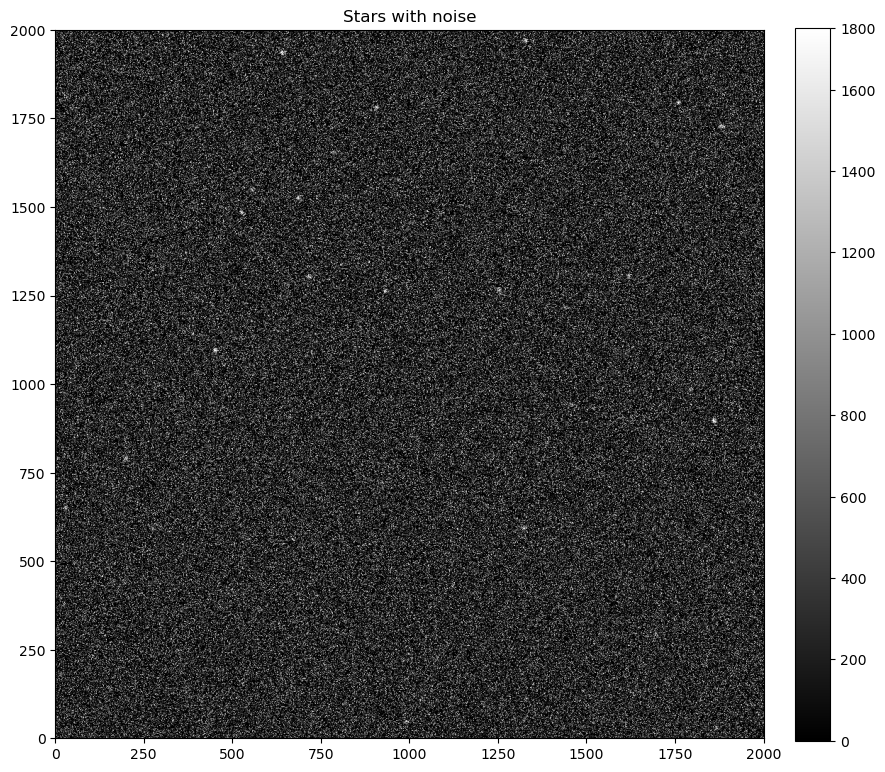

In [2]:
image = np.zeros([2000, 2000])
gain = 1.0
noise_amount = 1500

stars_w_noise = imsim.stars(image, 50, max_counts = 2500, fwhm = 10) + imsim.read_noise(image, noise_amount, gain=gain)
#imsim das estrelas (sem ruído) + imsim do ruído 
#percu em 50 = exagera o contraste para as estrelas ficarem mais aparentes (esconderia o ruído de fundo, destacando os picos); abaixo da mediana = preto

show_image(stars_w_noise, cmap='gray', percu=50)
plt.title('Stars with noise')

# Now an *incorrect* attempt at reducing noise

Notice that the call to the noise function has exactly the same arguments as above, in much the same way your camera’s electronics will have the same noise properties every time you read out an image. <br> However, the amount of noise has **increased**, not *decreased*. It’s much harder to pick out the stars in this image.

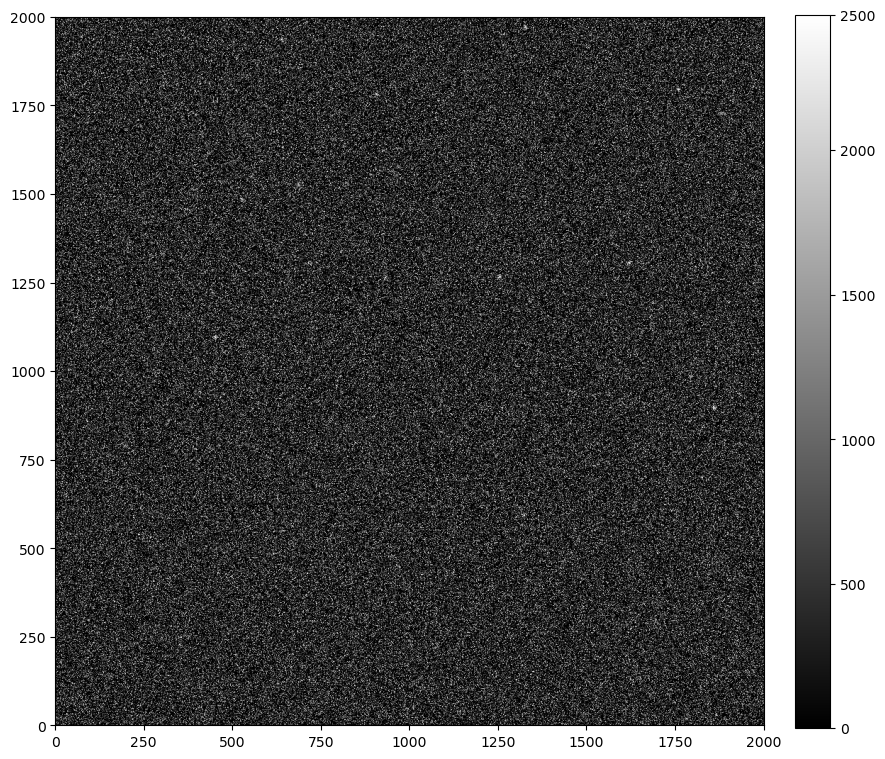

In [4]:
incorrect_attemptoremove_noise = stars_w_noise - imsim.read_noise(image, noise_amount, gain=gain)
show_image(incorrect_attemptoremove_noise, cmap='gray', percu=50)

# Every imagem has noise 

Every image, including calibration images like bias and dark frames, has noise. If we tried to calibrate images by taking a single bias image and a single dark image, the final result might well look worse than before the image is reduced.

For demonstration, we’ll see what happens below.

Note that here we construct realistic bias and dark, but leave read noise out of the flat; we’ll return to that point later.

# Parameters 4 CCD - Generate the image w/ noise - Uncalibrated images

These are the same as in the previous notebook, except for the read noise, which is $700e-,100$ times larger than in the previous notebook.

Add model sources:   0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1200x1200 with 0 Axes>

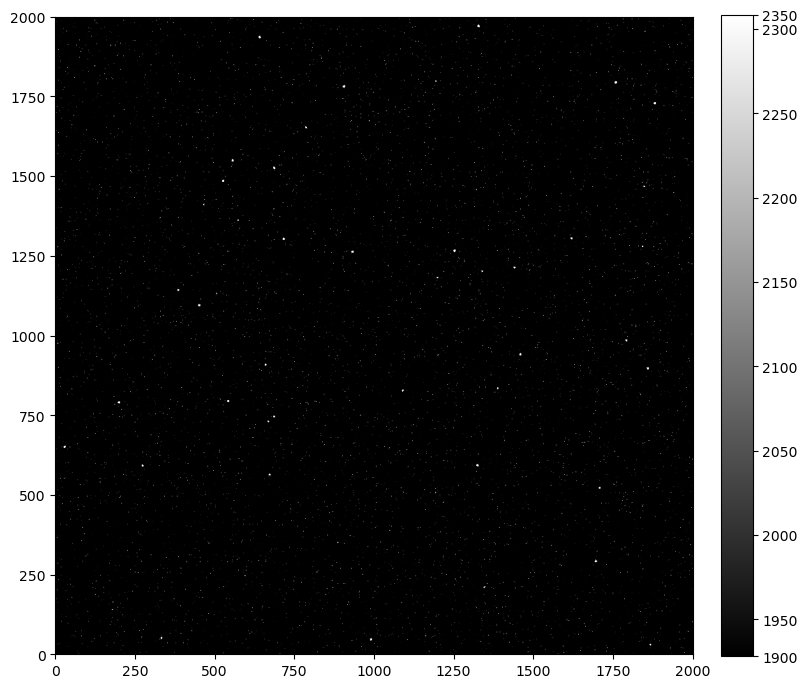

In [13]:
#parameters

gain = 1.0
star_exposure = 30.0
dark_exposure = 60.0
dark = 0.1
sky_counts = 20
bias_level = 1100
read_noise_electrons = 700 
max_stars_counts = 2000

#generate

bias_wnoise = (imsim.bias(image, bias_level, realistic=True) + imsim.read_noise(image, read_noise_electrons, gain=gain))

dark_frame_wnoise = (imsim.bias(image, bias_level, realistic=True) + 
                     imsim.dark_current(image, dark, dark_exposure, gain=gain, hot_pixels=True) +
                    imsim.read_noise(image, read_noise_electrons, gain=gain))

flat = imsim.sensitivity_variations(image)

realistic_stars = (imsim.stars(image, 50, max_counts = max_stars_counts) +
                  imsim.dark_current(image, dark, star_exposure, gain=gain, hot_pixels=True) +
                  imsim.bias(image, bias_level, realistic=True) +
                  imsim.read_noise(image, read_noise_electrons, gain=gain))

#Uncalibrated image - we’ll compare it to the calibrated version

plt.figure(figsize = (12,12))

show_image(realistic_stars, cmap='gray', percu=99.9, figsize=(9,9))

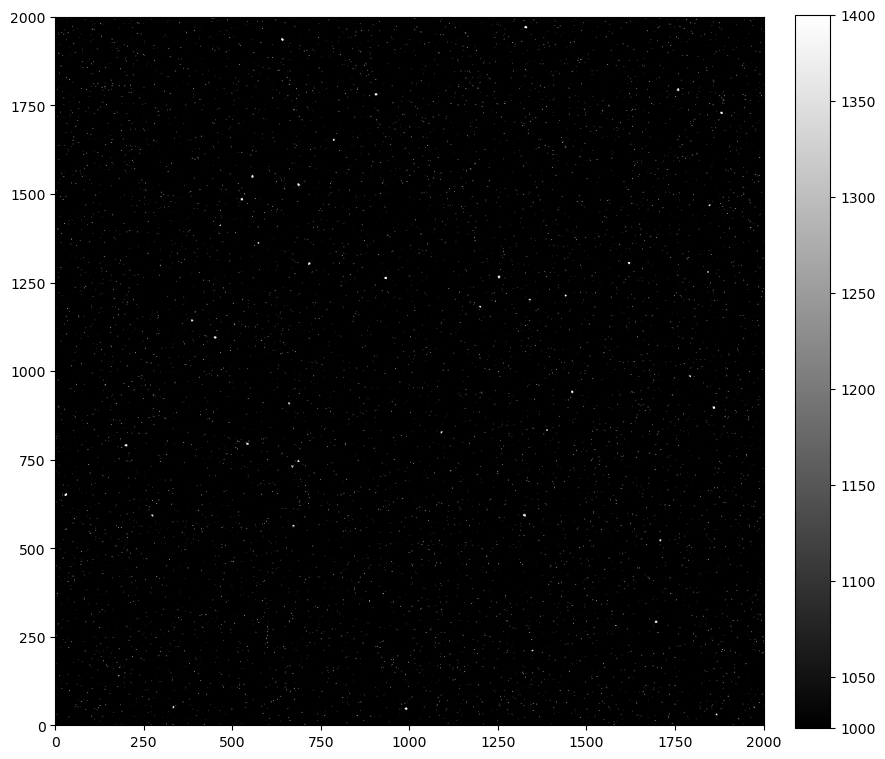

In [18]:
# Reduce (calibrate) the star image

    # First we calculate the dark current, scaled to the exposure time of our light image.

scaled_dark_current = star_exposure * (dark_frame_wnoise - bias_wnoise) / dark_exposure

#Next, we subtract the bias and dark current from the star image and then apply the flat correction.

calibrated_stars = (realistic_stars - bias_wnoise - scaled_dark_current) / flat
show_image(calibrated_stars, cmap='gray', percu=99.9)

# Reducing the image cleans up the image a bit

The stars stand more clearly than in the unreduced image.

This image does not look much better than the uncalibrated image, but remember that the read noise used in this simulated image, $700e^-$ per pixel, is unrealistically high. 

*Depois de subtrair bias, subtrair dark, e dividir pelo flat, as estrelas ficam mais visíveis. MAS ainda não ta mt bom não e isso pk o read_noise_electrons ta em 700, isso é 100x maior que o normal.*

# Reducing the image increases the noise in the image

The histogram below shows pixel values before and after calibration. The width of the distribution is a measure of the read noise. As expected, reducing the image increases the read noise. One reason one takes several calibration images of each type is to reduce the amount of noise in the calibration image. That will, in turn, keep the noise in the final image as small as possible.

*CADA imagem de calibração tem ruído (quando fez bias_with_noise = bias + ruído₁
                                    dark_frame_with_noise = bias + dark_current + ruído₂)* <br> 
*Então quando eu fiz calibrated_stars, propaguei os ruídos. O resultado é a variância (largura do histograma) aumenta.* <br> 
*A solução é o que vem no próximo notebook, quanto mais calibrações se tira e combina, MENOS ruído se ADICIONA na imagem final.*

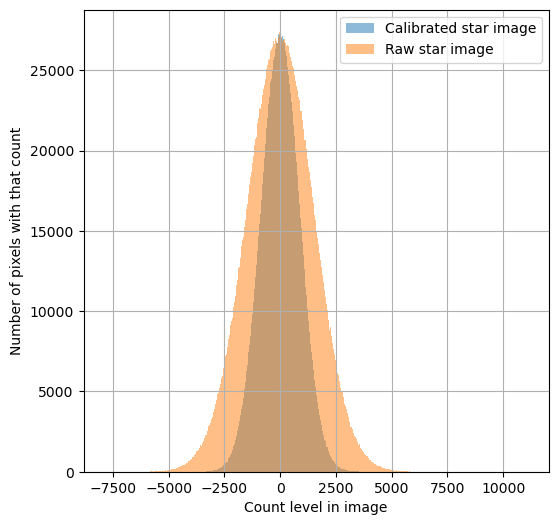

In [21]:
plt.figure(figsize=(6, 6))

hist(calibrated_stars.flatten(), bins='freedman', label='Calibrated star image', alpha=0.5)
hist(stars_w_noise.flatten(), bins='freedman', label='Raw star image', alpha=0.5)

plt.legend()
plt.grid()
plt.xlabel('Count level in image')
plt.ylabel('Number of pixels with that count');

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

- Raw image é o número que sai da camera em ADU
  
- Nesse notebook da pra tirar de importante que:
    - MATEMATICAMENTE é impossível remover o read noise da imagem e tentar fazer do jeito 'normal' só piora
    - Melhor exemplo: incorrect_attemptoremove_noise, pk mostra que o resultado não fica sem ruído e sim aumenta o ruído. Isso acontece pk o ruído é aleatório e não um valor fixo que pode subtrair.
    - Calibração é pra remover coisas que são previsíveis: bias, dark current e flat. Ruído não se tira, só 'gerenciamos' com múltiplas exposições.

---

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://github.com/nyny2903/astropy-coisas/tree/main<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-04-Nonuniform-sensitivity.html